Link Kaggle

Setting Up

In [1]:
!pip install -U opencv-python-headless

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

 Load and Fix the Labels

In [3]:
train_df = pd.read_csv('/content/asl_dataset/sign_mnist_train.csv')
test_df = pd.read_csv('/content/asl_dataset/sign_mnist_test.csv')

In [18]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB


In [4]:

# Apply the fix
X = train_df.drop('label', axis=1).values.astype('float32')
y = train_df['label'].values

X_test = test_df.drop('label', axis=1).values.astype('float32')
y_test_raw = test_df['label'].values
# Remap labels to 0-23
unique_labels = sorted(np.unique(y))

label_map = {old:new for new, old in enumerate(unique_labels)}

y = np.array([label_map[label] for label in y])
y_test_raw = np.array([label_map[label] for label in y_test_raw])

print(label_map)


{np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(10): 9, np.int64(11): 10, np.int64(12): 11, np.int64(13): 12, np.int64(14): 13, np.int64(15): 14, np.int64(16): 15, np.int64(17): 16, np.int64(18): 17, np.int64(19): 18, np.int64(20): 19, np.int64(21): 20, np.int64(22): 21, np.int64(23): 22, np.int64(24): 23}


In [5]:
print(label_map)

{np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(10): 9, np.int64(11): 10, np.int64(12): 11, np.int64(13): 12, np.int64(14): 13, np.int64(15): 14, np.int64(16): 15, np.int64(17): 16, np.int64(18): 17, np.int64(19): 18, np.int64(20): 19, np.int64(21): 20, np.int64(22): 21, np.int64(23): 22, np.int64(24): 23}


Preprocess the Images

In [6]:
# Normalize pixel values to 0-1 range
X = X / 255.0
X = X.reshape(-1, 28, 28, 1).astype('float32')

In [7]:
X_test = X_test / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')
# One-hot encode the labels
y = to_categorical(y, num_classes=24)
y_test = to_categorical(y_test_raw, num_classes=24)
# Create validation split (15% of training data)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    stratify=np.argmax(y, axis=1),
    random_state=42
)
print('Training samples:', X_train.shape[0])
print('Validation samples:', X_val.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 23336
Validation samples: 4119
Test samples: 7172


Build the CNN Architecture

In [8]:
import tensorflow as tf
#=============================
#cari tools buat visualize CNN layer
#===================================
def build_model():
    model = Sequential([

        # INPUT LAYER (best practice)
        tf.keras.layers.Input(shape=(28, 28, 1)),

        # First convolutional block
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        # Second convolutional block
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        # Third convolutional block
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),

        # OUTPUT
        Dense(24, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,904 (1.51 MB)

 Trainable params: 394,456 (1.50 MB)

 Non-trainable params: 448 (1.75 KB)

Set Up Data Augmentation

In [9]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)
datagen.fit(X_train)

Configure Training Callbacks

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'asl_best.h5',
        monitor='val_loss',
        save_best_only=True
    )
]

Train the Model

In [11]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    steps_per_epoch=max(1, len(X_train)//128),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/20


182/182 - 21s - 118ms/step - accuracy: 0.2209 - loss: 2.8559 - val_accuracy: 0.0636 - val_loss: 3.2879 - learning_rate: 1.0000e-04
Epoch 2/20


182/182 - 17s - 92ms/step - accuracy: 0.4670 - loss: 1.7387 - val_accuracy: 0.2192 - val_loss: 2.5369 - learning_rate: 1.0000e-04
Epoch 3/20


182/182 - 20s - 109ms/step - accuracy: 0.6130 - loss: 1.2363 - val_accuracy: 0.8031 - val_loss: 0.9393 - learning_rate: 1.0000e-04
Epoch 4/20


182/182 - 17s - 92ms/step - accuracy: 0.7151 - loss: 0.9109 - val_accuracy: 0.9281 - val_loss: 0.3957 - learning_rate: 1.0000e-04
Epoch 5/20


...

182/182 - 17s - 93ms/step - accuracy: 0.9402 - loss: 0.1916 - val_accuracy: 0.9925 - val_loss: 0.0401 - learning_rate: 1.0000e-04
Epoch 15/20
182/182 - 5s - 30ms/step - accuracy: 0.9062 - loss: 0.2031 - val_accuracy: 0.9922 - val_loss: 0.0414 - learning_rate: 1.0000e-04
Epoch 16/20


182/182 - 16s - 90ms/step - accuracy: 0.9441 - loss: 0.1774 - val_accuracy: 0.9978 - val_loss: 0.0222 - learning_rate: 1.0000e-04
Epoch 17/20


182/182 - 17s - 91ms/step - accuracy: 0.9578 - loss: 0.1445 - val_accuracy: 0.9990 - val_loss: 0.0168 - learning_rate: 1.0000e-04
Epoch 18/20


182/182 - 18s - 100ms/step - accuracy: 0.9590 - loss: 0.1382 - val_accuracy: 0.9998 - val_loss: 0.0143 - learning_rate: 1.0000e-04
Epoch 19/20
182/182 - 17s - 94ms/step - accuracy: 0.9583 - loss: 0.1323 - val_accuracy: 0.9971 - val_loss: 0.0151 - learning_rate: 1.0000e-04
Epoch 20/20


182/182 - 3s - 15ms/step - accuracy: 0.9219 - loss: 0.1402 - val_accuracy: 0.9978 - val_loss: 0.0141 - learning_rate: 1.0000e-04


Evaluate Model Performance

In [12]:
import seaborn as sns

# Bandingin dengan model basis CNN lain (cth YOLO)

Test accuracy: 97.30%
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
              precision    recall  f1-score   support

           0     0.9910    1.0000    0.9955       331
           1     1.0000    1.0000    1.0000       432
           2     1.0000    1.0000    1.0000       310
           3     1.0000    0.9918    0.9959       245
           4     0.9138    1.0000    0.9549       498
           5     1.0000    1.0000    1.0000       247
           6     0.9412    0.9655    0.9532       348
           7     1.0000    0.9541    0.9765       436
           8     0.9763    1.0000    0.9880       288
           9     1.0000    0.9698    0.9847       331
          10     0.9127    1.0000    0.9543       209
          11     0.9581    0.9873    0.9725       394
          12     0.9748    0.9313    0.9525       291
          13     1.0000    1.0000    1.0000       246
          14     1.0000    1.0000    1.0000       347
          15     0.9820    1.0000    0.9909       164
          16     

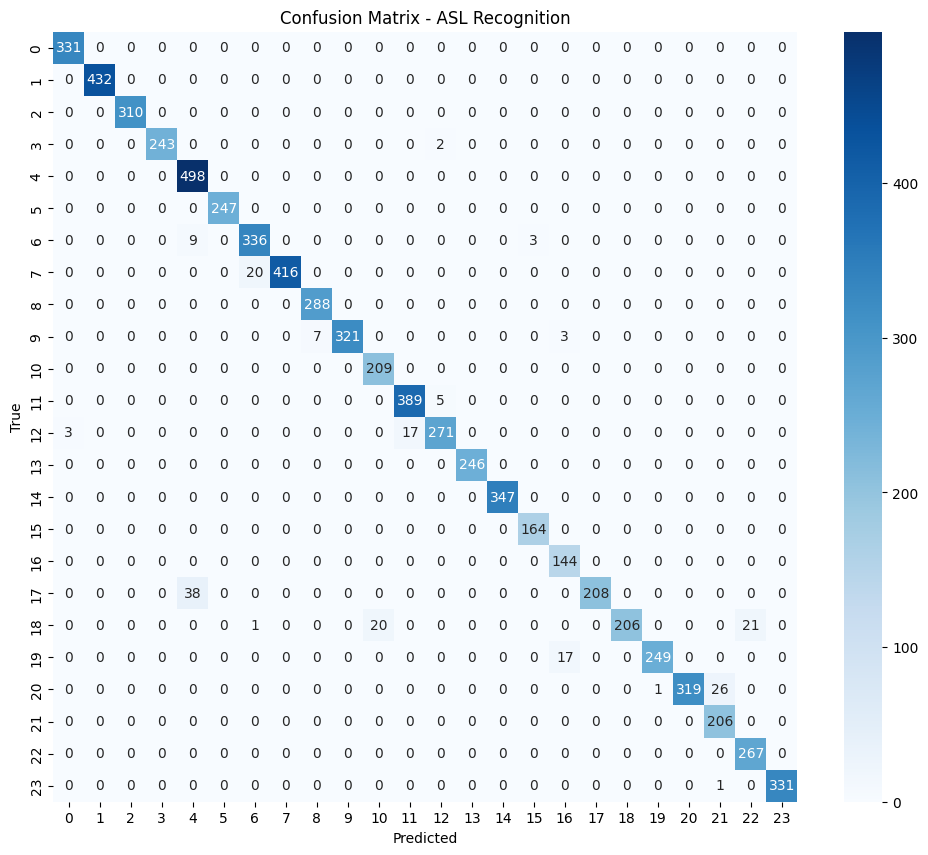

In [13]:
# Load the best saved model
model = build_model()
from tensorflow.keras.models import load_model

model = load_model('asl_best.h5')
# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc*100:.2f}%")
# Get detailed predictions
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
# Classification report shows precision, recall, F1 for each letter
print(classification_report(y_true, y_pred, digits=4))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ASL Recognition')
plt.show()


Save the Model and Class Mappings

In [14]:
# Save the complete model
model.save('asl_final.h5')

In [16]:
# Create letter mapping (A-Y, excluding J and Z)
import string
letters = [c for c in string.ascii_uppercase if c not in ('J', 'Z')]
with open('classes_letters.json', 'w') as f:
    json.dump(letters, f)
# Download files from Colab
from google.colab import files
files.download('asl_final.h5')
files.download('classes_letters.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>